### CodeAlpha Task 3
---

**Author** : Aditi Singh

---
TASK : Sales Prediction using Python

● Predict future sales based on factors like advertising spend, target segment and platform.

● Prepare data through cleaning, transformation and feature selection.

● Use regression or time series models to forecast sales.

● Analyze how changes in advertising impact sales outcomes.

● Deliver actionable insights for business marketing strategies.

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


In [11]:
df = pd.read_csv("/content/Advertising.csv")

In [12]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.shape

(200, 5)

In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# Basic statistics
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## Feature Selection — Correlation Analysis

Correlation with Sales:
Unnamed: 0   -0.0516
TV            0.7822
Radio         0.5762
Newspaper     0.2283
Name: Sales, dtype: float64


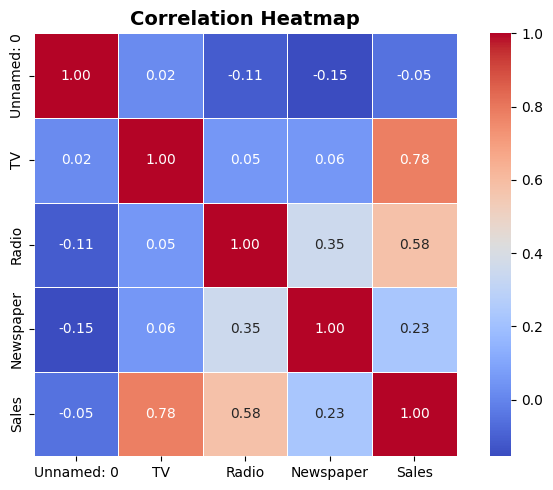

In [17]:
# Correlation with Sales
corr = df.corr()['Sales'].drop('Sales')
print("Correlation with Sales:")
print(corr.round(4))

# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

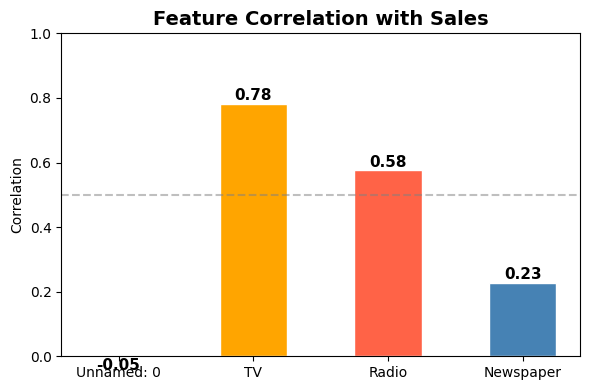

In [18]:
# Correlation bar chart
plt.figure(figsize=(6, 4))
colors = ['steelblue', 'orange', 'tomato']
bars = plt.bar(corr.index, corr.values, color=colors, edgecolor='white', width=0.5)
for b, v in zip(bars, corr.values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}',
             ha='center', fontsize=11, fontweight='bold')
plt.title('Feature Correlation with Sales', fontsize=14, fontweight='bold')
plt.ylabel('Correlation')
plt.ylim(0, 1)
plt.axhline(0.5, color='gray', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Data Visualization — Advertising vs Sales

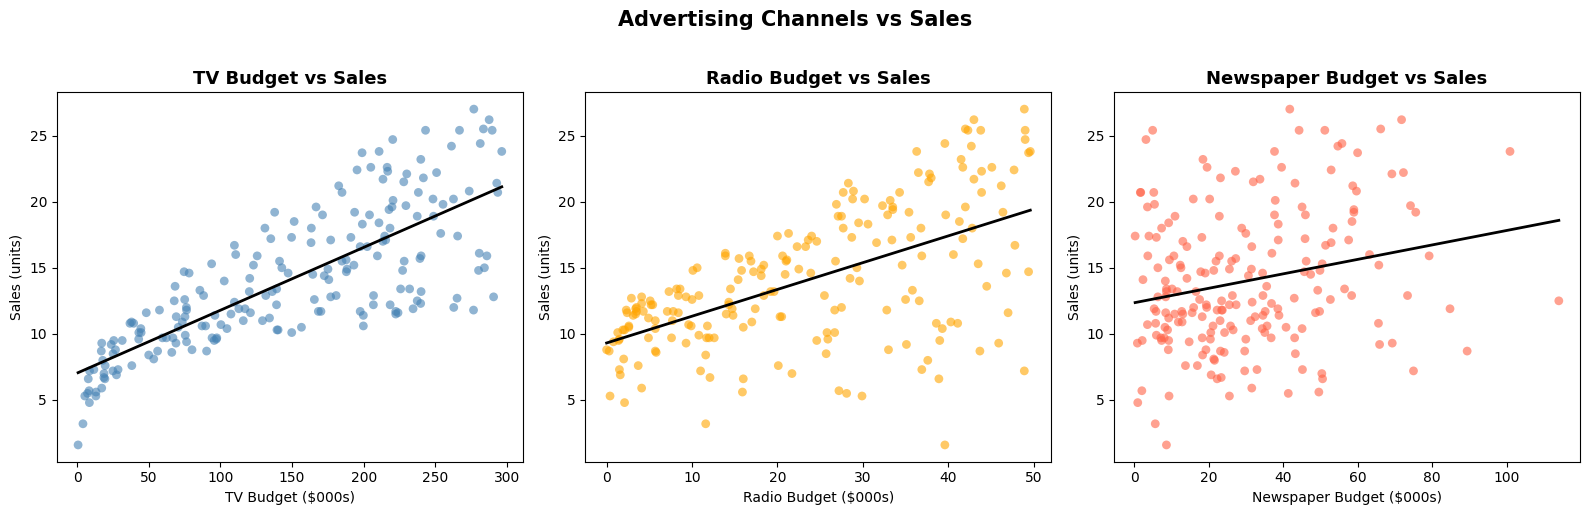

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
channels = ['TV', 'Radio', 'Newspaper']
colors   = ['steelblue', 'orange', 'tomato']

for ax, col, clr in zip(axes, channels, colors):
    ax.scatter(df[col], df['Sales'], color=clr, alpha=0.6, s=40, edgecolors='none')
    m, b = np.polyfit(df[col], df['Sales'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', lw=2)
    ax.set_title(f'{col} Budget vs Sales', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{col} Budget ($000s)')
    ax.set_ylabel('Sales (units)')

plt.suptitle('Advertising Channels vs Sales', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

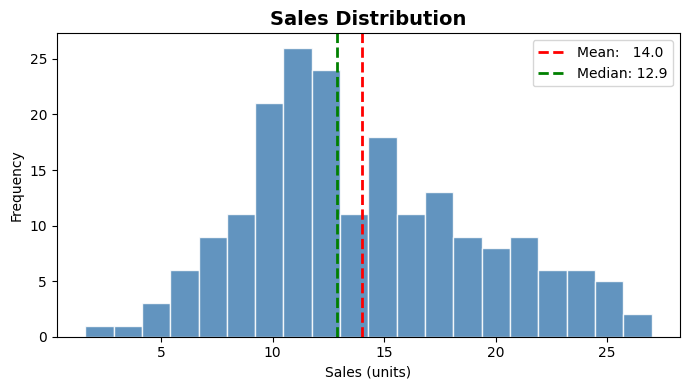

In [20]:
# Sales distribution
plt.figure(figsize=(7, 4))
plt.hist(df['Sales'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df['Sales'].mean(),   color='red',   lw=2, ls='--', label=f'Mean:   {df["Sales"].mean():.1f}')
plt.axvline(df['Sales'].median(), color='green', lw=2, ls='--', label=f'Median: {df["Sales"].median():.1f}')
plt.title('Sales Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sales (units)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Prepare Data — Train / Test Split

In [21]:
X = df[['TV', 'Radio', 'Newspaper']]  # Features
y = df['Sales']                        # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
X_train.head()

Training samples : 160
Testing  samples : 40


,TV,Radio,Newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6


## Train Models

## Model 1 — Linear Regression

In [22]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Coefficients
print("Coefficients:")
for feat, coef in zip(X.columns, lr.coef_):
    print(f"  {feat:10s}: {coef:.4f}")
print(f"  Intercept : {lr.intercept_:.4f}")

Coefficients:
  TV        : 0.0447
  Radio     : 0.1892
  Newspaper : 0.0028
  Intercept : 2.9791


### Model 2 — Random Forest Regressor

In [23]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest trained with 100 trees ")

Random Forest trained with 100 trees 


## Evaluate Models

In [24]:
results = []
for name, pred in [('Linear Regression', lr_pred), ('Random Forest', rf_pred)]:
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    results.append({'Model': name, 'R² Score': round(r2,4),
                    'RMSE': round(rmse,4), 'MAE': round(mae,4)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model  R² Score   RMSE    MAE
Linear Regression    0.8994 1.7816 1.4608
    Random Forest    0.9813 0.7686 0.6201


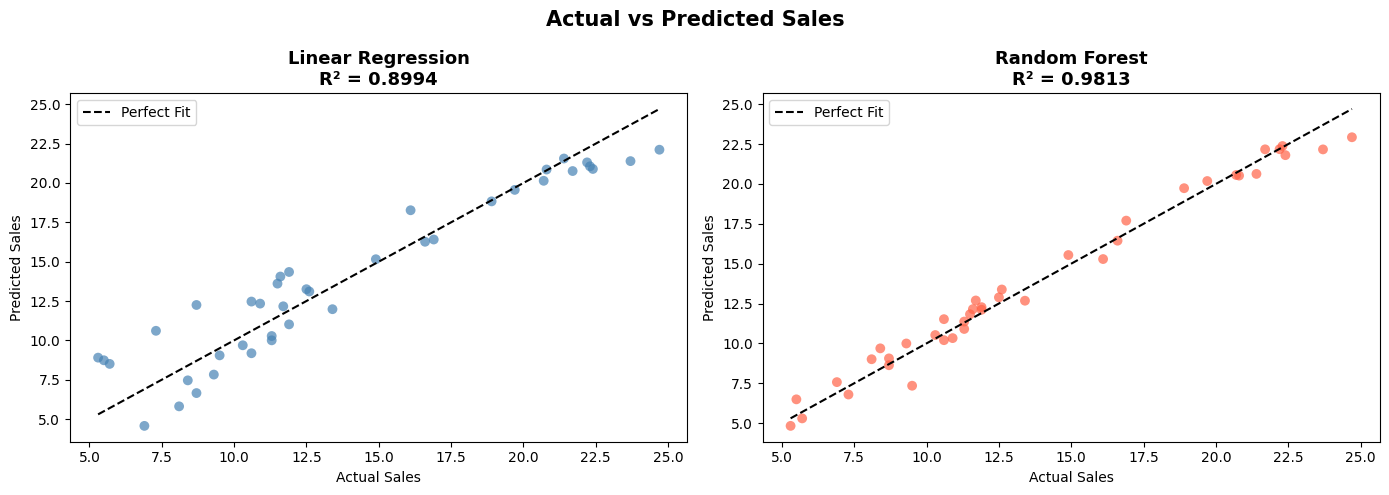

In [25]:
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name, clr in zip(
        axes,
        [lr_pred, rf_pred],
        ['Linear Regression', 'Random Forest'],
        ['steelblue', 'tomato']):
    r2 = r2_score(y_test, pred)
    ax.scatter(y_test, pred, color=clr, alpha=0.7, s=50, edgecolors='none')
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Fit')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')
    ax.legend()

plt.suptitle('Actual vs Predicted Sales', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

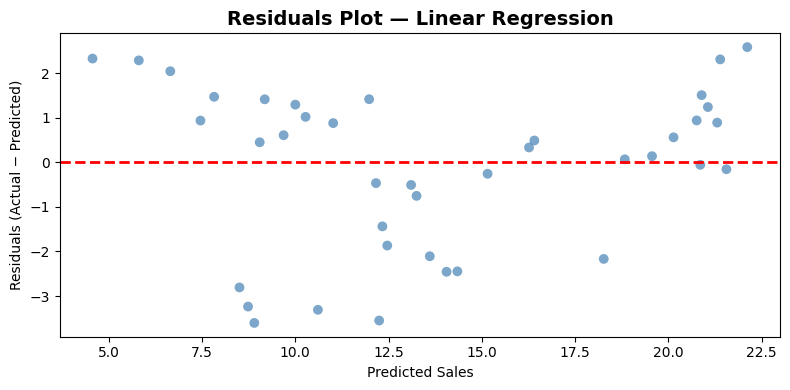

In [26]:
# Residuals plot
residuals = y_test.values - lr_pred
plt.figure(figsize=(8, 4))
plt.scatter(lr_pred, residuals, color='steelblue', alpha=0.7, s=50, edgecolors='none')
plt.axhline(0, color='red', lw=2, ls='--')
plt.title('Residuals Plot — Linear Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual − Predicted)')
plt.tight_layout()
plt.show()

## Feature Importance & Advertising Impact

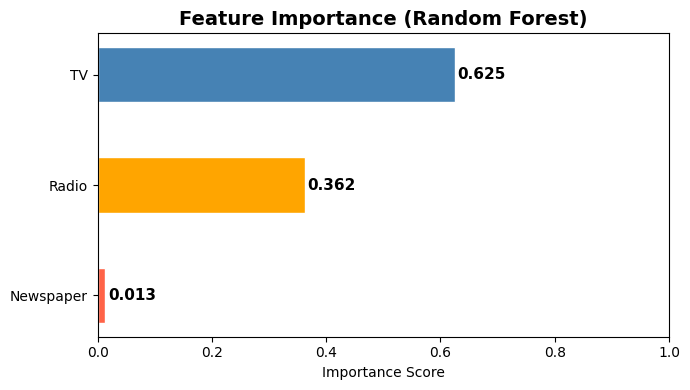

In [27]:
# Random Forest feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7, 4))
colors = ['tomato', 'orange', 'steelblue']
bars = plt.barh(importance.index, importance.values, color=colors,
                edgecolor='white', height=0.5)
for b, v in zip(bars, importance.values):
    plt.text(v + 0.005, b.get_y() + b.get_height()/2, f'{v:.3f}',
             va='center', fontsize=11, fontweight='bold')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [28]:
# Sales change per $1000 increase in each channel (Linear Regression)
print("Advertising Impact on Sales (per $1000 increase):")
print(f"  TV        → +{lr.coef_[0]:.4f} units")
print(f"  Radio     → +{lr.coef_[1]:.4f} units  ← Best ROI per dollar")
print(f"  Newspaper → +{lr.coef_[2]:.4f} units  ← Very low impact")

Advertising Impact on Sales (per $1000 increase):
  TV        → +0.0447 units
  Radio     → +0.1892 units  ← Best ROI per dollar
  Newspaper → +0.0028 units  ← Very low impact


## Predict Future Sales — Budget Scenarios

In [29]:
scenarios = pd.DataFrame({
    'Scenario'  : ['Low Budget', 'Balanced', 'TV Heavy', 'Radio Heavy', 'High Budget'],
    'TV'        : [50,  150, 300, 100, 280],
    'Radio'     : [5,   30,  10,  50,  45],
    'Newspaper' : [10,  20,  10,  20,  50]
})
scenarios['Predicted_Sales'] = lr.predict(
    scenarios[['TV', 'Radio', 'Newspaper']]).round(2)

print(scenarios.to_string(index=False))

   Scenario  TV  Radio  Newspaper  Predicted_Sales
 Low Budget  50      5         10             6.19
   Balanced 150     30         20            15.42
   TV Heavy 300     10         10            18.32
Radio Heavy 100     50         20            16.97
High Budget 280     45         50            24.16


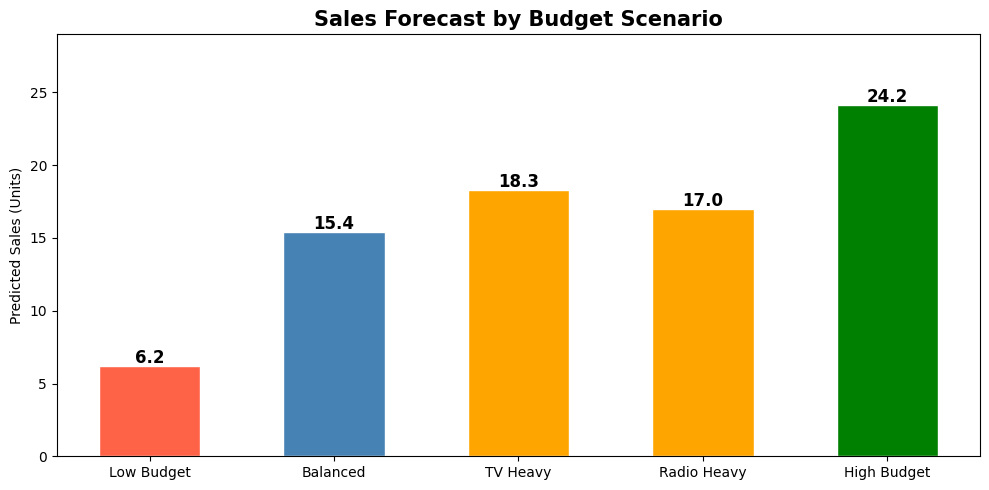

In [30]:
# Scenario bar chart
plt.figure(figsize=(10, 5))
bar_colors = ['tomato', 'steelblue', 'orange', 'orange', 'green']
bars = plt.bar(scenarios['Scenario'], scenarios['Predicted_Sales'],
               color=bar_colors, edgecolor='white', width=0.55)
for b, v in zip(bars, scenarios['Predicted_Sales']):
    plt.text(b.get_x() + b.get_width()/2, v + 0.2, f'{v:.1f}',
             ha='center', fontsize=12, fontweight='bold')
plt.title('Sales Forecast by Budget Scenario', fontsize=15, fontweight='bold')
plt.ylabel('Predicted Sales (Units)')
plt.ylim(0, scenarios['Predicted_Sales'].max() * 1.2)
plt.tight_layout()
plt.show()

## Actionable Business Insights

In [33]:
print("=" * 60)
print("            ACTIONABLE BUSINESS INSIGHTS")
print("=" * 60)
insights = [
    "1. TV advertising has the STRONGEST correlation (0.78) with sales.",
    "2. Radio gives the BEST ROI — +0.19 sales per $1000 spent.",
    "3. Newspaper has almost ZERO impact — reallocate that budget.",
    "4. Best strategy: High TV + High Radio → max sales.",
    "5. Linear Regression R² = 0.90 (explains 90% of variance).",
    "6. Random Forest R² = 0.98 — very high accuracy.",
    "7. High Budget scenario (TV=280, R=45) predicts ~24 units.",
    "8. Low Budget scenario predicts only ~6 units — spend matters!",
]
for tip in insights:
    print(f"   {tip}")
print("=" * 60)

            ACTIONABLE BUSINESS INSIGHTS
   1. TV advertising has the STRONGEST correlation (0.78) with sales.
   2. Radio gives the BEST ROI — +0.19 sales per $1000 spent.
   3. Newspaper has almost ZERO impact — reallocate that budget.
   4. Best strategy: High TV + High Radio → max sales.
   5. Linear Regression R² = 0.90 (explains 90% of variance).
   6. Random Forest R² = 0.98 — very high accuracy.
   7. High Budget scenario (TV=280, R=45) predicts ~24 units.
   8. Low Budget scenario predicts only ~6 units — spend matters!


## Actionable Business Insights

The analysis provides several practical recommendations for optimizing advertising expenditure and maximizing sales performance.

## Result

A sales prediction model was successfully developed using advertising expenditure data from TV, Radio, and Newspaper channels. Multiple regression models were trained and evaluated, including Linear Regression and Random Forest Regressor.

The Random Forest model achieved the highest prediction accuracy, outperforming Linear Regression. Analysis showed that TV advertising has the strongest influence on sales, followed by Radio advertising, while Newspaper advertising contributes the least.

Future budget scenario testing demonstrated that increasing investment in high-performing advertising channels significantly improves predicted sales outcomes.


## Conclusion

This project successfully applied machine learning techniques to predict sales based on advertising expenditure. Data cleaning, exploratory data analysis, feature selection, model training, and evaluation were performed to understand the relationship between advertising investments and sales performance.

The results revealed that TV advertising is the most influential factor affecting sales, while Radio advertising also contributes positively. Newspaper advertising showed comparatively lower impact on sales growth. Among the evaluated models, the Random Forest Regressor provided the most accurate predictions.

The insights generated from this analysis can help businesses optimize marketing budgets, focus on high-performing advertising channels, and make data-driven decisions to maximize return on investment and improve future sales performance.
